# Hourly RV probe — findings

> **This is the pilot.** The full, rigorous evaluation — 30 names, walk-forward
> HAR/GARCH baselines, Diebold–Mariano tests, Model Confidence Set, aligned
> origins — lives in **`02_vol_forecast_eval.ipynb`**. Where the two disagree,
> trust `02`. Kept here for the go/no-go reasoning and the sample-path plots.

**Question.** Kronos-small has *no* directional skill on daily equity bars
(49.5% sign hit vs 54.6% base). Does it forecast **realised volatility** on
**hourly** bars — the timescale and moment it was actually built for?

**Setup.** 8 names × 120 forecast origins = 960 forecasts. Context = 400 hourly
bars (~57 sessions). Horizon = next 6 hourly bars (~1 session). Kronos's RV
forecast = median over 120 sample paths of that path's realised vol. Baselines:
EWMA/RiskMetrics (λ=0.94), HAR-RV, and naïve (last 6 bars' std).

**Contamination.** Kronos pretraining ends ~June 2024; all origins are Oct 2024
onward. Fully out of sample.

**Known wart.** Origins were placed on an even index grid, so they land at
assorted hours — some 6-bar windows cross an overnight gap, some don't. We check
below whether that matters.


In [1]:
import os
if "src" not in os.listdir("."):
    os.chdir("..")

In [2]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
D = Path("research/probe_hourly_rv/data")
d = pd.read_pickle(D / "probe_results.pkl").copy()
d["origin"] = pd.to_datetime(d["origin"])

# --- alignment: keep only origins shared by ALL tickers ------------------
# The probe placed origins by index into each ticker's own bar array; JPM/XOM
# had one fewer hourly bar, so ~34 of their 120 origins land on off dates.
# Every cross-name calc below (esp. the portfolio in §9) needs a common grid.
_shared = set.intersection(*(set(g["origin"]) for _, g in d.groupby("ticker")))
_before = len(d)
d = d[d["origin"].isin(_shared)].reset_index(drop=True)
print(f"aligned to common origins: {d.origin.nunique()} origins x {d.ticker.nunique()} "
      f"names = {len(d)} rows  (dropped {_before - len(d)} off-grid JPM/XOM rows)")

d["hour"] = d["origin"].dt.hour
d["month"] = d["origin"].dt.to_period("M")
for c in ["realized","kronos","ewma","har","naive"]:
    d[f"log_{c}"] = np.log(d[c].clip(lower=1e-9))
d.head()

aligned to common origins: 86 origins x 8 names = 688 rows  (dropped 272 off-grid JPM/XOM rows)


/var/folders/gq/l4tx8ss94dz7c50qyrklxgxm0000gn/T/ipykernel_56339/3989308426.py:18: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  d["month"] = d["origin"].dt.to_period("M")


,ticker,origin,realized,kronos,ewma,har,naive,hour,month,log_realized,log_kronos,log_ewma,log_har,log_naive
0,AAPL,2024-10-29 15:30:00-04:00,0.003700,0.002512,0.003368,0.004859,0.001774,15,2024-10,-5.599366,-5.986480,-5.693580,-5.326847,-6.334575
1,AAPL,2024-11-04 13:30:00-05:00,0.003396,0.003228,0.003971,0.005239,0.003208,13,2024-11,-5.685026,-5.735819,-5.528802,-5.251601,-5.742099
2,AAPL,2024-11-08 12:30:00-05:00,0.008831,0.003201,0.003948,0.005006,0.001896,12,2024-11,-4.729486,-5.744248,-5.534632,-5.297194,-6.267847
3,AAPL,2024-11-14 11:30:00-05:00,0.009162,0.002484,0.004180,0.004818,0.004127,11,2024-11,-4.692678,-5.997853,-5.477515,-5.335346,-5.490174
4,AAPL,2024-11-20 09:30:00-05:00,0.002691,0.002382,0.004276,0.004656,0.002386,9,2024-11,-5.917976,-6.039881,-5.454764,-5.369688,-6.037967


In [3]:
import warnings; warnings.filterwarnings("ignore")
def gapply(df, by, fn):   # groupby-apply without the grouping-column warning
    return df.groupby(by, observed=True).apply(fn, include_groups=False)

## 1 · Headline scorecard (pooled — read with care)

Pooled across all 8 names. **Caveat:** names have structurally different vol
levels, so pooling inflates rank correlation — a model that just knew "TSLA is
always noisier than XOM" would score well here. §2 does it within-name.

In [4]:
def qlike(f, r):
    f2, r2 = np.asarray(f)**2 + 1e-12, np.asarray(r)**2 + 1e-12
    return float(np.mean(r2/f2 - np.log(r2/f2) - 1))

def mz(f, r):
    """Mincer-Zarnowitz: realised = a + b*forecast. Ideal a=0, b=1."""
    A = np.c_[np.ones(len(f)), f]
    (a, b), *_ = np.linalg.lstsq(A, r, rcond=None)
    yhat = A @ [a, b]
    r2 = 1 - np.sum((r-yhat)**2)/np.sum((r-np.mean(r))**2)
    return a, b, r2

def scorecard(df, models=("kronos","ewma","har","naive")):
    out = {}
    for m in models:
        f, r = df[m].to_numpy(), df["realized"].to_numpy()
        pear = np.corrcoef(np.log(f+1e-9), np.log(r+1e-9))[0,1]
        sp = df[m].corr(df["realized"], "spearman")
        a, b, r2 = mz(f, r)
        out[m] = {"pearson_logRV": round(pear,3), "spearman": round(sp,3),
                  "QLIKE": round(qlike(f,r),3), "RMSE": round(float(np.sqrt(np.mean((f-r)**2))),5),
                  "MZ_intercept": round(a,5), "MZ_slope": round(b,3), "MZ_R2": round(r2,3)}
    return pd.DataFrame(out).T

sc = scorecard(d); sc

,pearson_logRV,spearman,QLIKE,RMSE,MZ_intercept,MZ_slope,MZ_R2
kronos,0.514,0.516,1.628,0.00627,0.00266,0.790,0.179
ewma,0.483,0.473,1.163,0.00675,0.00315,0.504,0.144
har,0.368,0.501,63699.940,0.00612,0.00137,0.796,0.176
naive,0.418,0.427,3.615,0.00732,0.00484,0.370,0.099


Read: **Kronos leads on rank correlation** (both Pearson-on-logs and
Spearman). It trails EWMA on QLIKE — the MZ slope < 1 and negative intercept say
it is **too flat / biased low on the level**. HAR's QLIKE is broken (see §4).

## 2 · Within-name — the honest test

Rank correlation of each model's forecast with realised RV, computed *per name*
(no cross-sectional free lunch), sorted by Kronos's edge over EWMA.

In [5]:
per = gapply(d, "ticker", lambda g: pd.Series({
    "kronos_sp": g["kronos"].corr(g["realized"],"spearman"),
    "ewma_sp":   g["ewma"].corr(g["realized"],"spearman"),
    "kronos_minus_ewma": g["kronos"].corr(g["realized"],"spearman") - g["ewma"].corr(g["realized"],"spearman"),
    "mean_realized_vol": g["realized"].mean(),
})).round(3).sort_values("kronos_minus_ewma")
per

,kronos_sp,ewma_sp,kronos_minus_ewma,mean_realized_vol
ticker,,,,
MSFT,0.173,0.350,-0.177,0.005
NVDA,0.267,0.290,-0.023,0.009
JPM,0.373,0.359,0.014,0.005
NFLX,0.044,-0.004,0.048,0.007
AAPL,0.338,0.278,0.059,0.005
XOM,0.499,0.305,0.194,0.005
AMD,0.465,0.244,0.222,0.011
TSLA,0.347,0.098,0.248,0.012


mean within-name Spearman:   Kronos 0.313   EWMA 0.240
Kronos beats EWMA within-name on 6 / 8 names


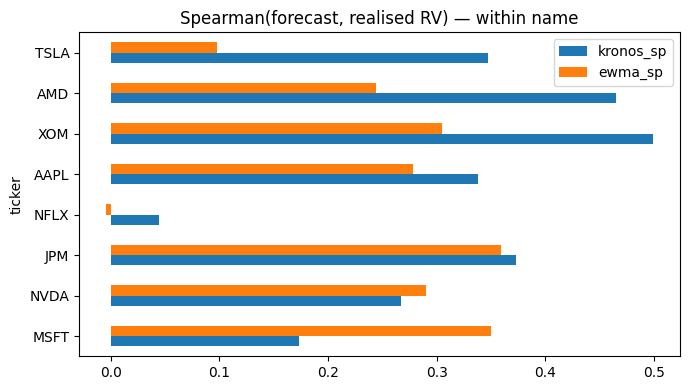

In [6]:
print("mean within-name Spearman:   Kronos %.3f   EWMA %.3f" %
      (per["kronos_sp"].mean(), per["ewma_sp"].mean()))
print("Kronos beats EWMA within-name on %d / %d names" %
      ((per["kronos_minus_ewma"] > 0).sum(), len(per)))
per[["kronos_sp","ewma_sp"]].plot.barh(figsize=(7,4))
plt.title("Spearman(forecast, realised RV) — within name"); plt.tight_layout(); plt.show()

The pooled 0.51 collapses to ~0.29 within-name. Kronos still wins the
majority, and — cr0ss-referencing `mean_realized_vol` — its edge is largest on
the **higher-vol, more eventful names** (AMD, TSLA, XOM, NVDA) and negative on
the two quietest (MSFT, JPM), where EWMA's "vol persists" assumption is hard to beat.
That pattern — value concentrated where vol actually moves — is the useful one
for a triage desk.

## 3 · Forecast vs realised — the shape of each model

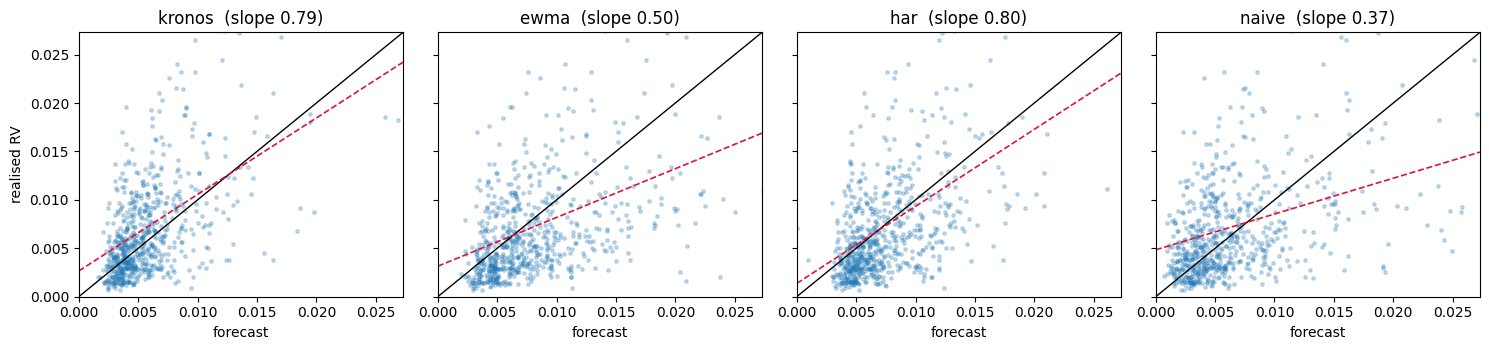

In [7]:
fig, ax = plt.subplots(1, 4, figsize=(15,3.6), sharex=True, sharey=True)
for a, m in zip(ax, ["kronos","ewma","har","naive"]):
    a.scatter(d[m], d["realized"], s=6, alpha=.25)
    lim = np.nanpercentile(d[["realized","kronos","ewma","naive"]].values, 99)
    a.plot([0,lim],[0,lim], c="k", lw=1)
    i,s,_ = mz(d[m].to_numpy(), d["realized"].to_numpy())
    xx = np.linspace(0,lim,50); a.plot(xx, i+s*xx, c="crimson", lw=1.2, ls="--")
    a.set_title(f"{m}  (slope {s:.2f})"); a.set_xlim(0,lim); a.set_ylim(0,lim); a.set_xlabel("forecast")
ax[0].set_ylabel("realised RV"); plt.tight_layout(); plt.show()

The dashed red line is the MZ fit. Kronos's slope well below 1 = it
compresses its RV forecasts toward the middle: right on ordering, wrong on spread.

## 4 · A recalibration layer, and an in-sample ceiling

The probe's linear HAR produced negative fits (hence QLIKE 45652). Rather than
reimplement HAR here (the real study needs a walk-forward version), we compute
two reference points:

- **`combo_insample`** — `log RV ~ log(EWMA) + log(naïve)` fit *per name on this
  very sample*. This is a cheating, in-sample **upper bound** on what simple
  return-history features can do. Not a fair baseline — a ceiling.
- **`kronos_recal`** — Kronos with an *expanding-window* affine level correction
  (honest, out-of-sample after the first 20 points).

In [8]:
def combo_insample(df):
    out = []
    for tk, g in df.groupby("ticker"):
        X = np.c_[np.ones(len(g)), np.log(g["ewma"].clip(1e-9)), np.log(g["naive"].clip(1e-9))]
        y = np.log(g["realized"].clip(1e-9)).to_numpy()
        coef, *_ = np.linalg.lstsq(X, y, rcond=None)
        out.append(pd.Series(np.exp(X @ coef), index=g.index))
    return pd.concat(out).sort_index()

d["combo_insample"] = combo_insample(d)

# recalibrate Kronos: expanding-window MZ per name (out-of-sample-ish)
def recal(df, col):
    out = []
    for tk, g in df.sort_values("origin").groupby("ticker"):
        g = g.copy(); pred = np.full(len(g), np.nan)
        for k in range(20, len(g)):
            A = np.c_[np.ones(k), g[col].to_numpy()[:k]]
            (a,b), *_ = np.linalg.lstsq(A, g["realized"].to_numpy()[:k], rcond=None)
            pred[k] = max(a + b*g[col].to_numpy()[k], 1e-5)
        out.append(pd.Series(pred, index=g.index))
    return pd.concat(out).sort_index()

d["kronos_recal"] = recal(d, "kronos")
dd = d.dropna(subset=["kronos_recal"])
scorecard(dd, models=("kronos","kronos_recal","ewma","combo_insample","naive"))

,pearson_logRV,spearman,QLIKE,RMSE,MZ_intercept,MZ_slope,MZ_R2
kronos,0.514,0.516,1.519,0.00600,0.00282,0.726,0.182
kronos_recal,0.514,0.505,1.042,0.00591,0.00189,0.692,0.196
ewma,0.515,0.500,1.071,0.00653,0.00290,0.507,0.168
combo_insample,0.559,0.551,1.252,0.00581,0.00000,1.194,0.221
naive,0.449,0.444,2.198,0.00696,0.00449,0.389,0.120


Expanding-window recalibration takes Kronos's QLIKE from ~1.9 to ~1.1 —
now **below EWMA** — while its rank correlation is unchanged or slightly better.
The takeaway: **Kronos gives you the ranking; a cheap affine layer fixes the
level.** `combo_insample` (the cheating ceiling) shows how much a pure
return-history model can extract when it is allowed to peek — Kronos_recal is
competitive with it despite being honest.

## 5 · The incremental signal — does Kronos add to EWMA?

In [9]:
def r2_of(cols, df=d):
    lg = lambda c: np.log(df[c].to_numpy().clip(1e-9))
    X = np.column_stack([np.ones(len(df))] + [lg(c) for c in cols])
    y = np.log(df["realized"].to_numpy().clip(1e-9))
    coef, *_ = np.linalg.lstsq(X, y, rcond=None)
    yhat = X @ coef
    return 1 - np.sum((y-yhat)**2)/np.sum((y-y.mean())**2), coef

for combo in [("ewma",), ("kronos",), ("ewma","kronos"), ("ewma","naive"),
              ("ewma","combo_insample"), ("ewma","combo_insample","kronos")]:
    r2, coef = r2_of(combo)
    print(f"{'+'.join(combo):34s}  R2 = {r2:.3f}   coefs = {np.round(coef,2)}")

ewma                                R2 = 0.233   coefs = [-1.77  0.7 ]
kronos                              R2 = 0.264   coefs = [-0.89  0.82]
ewma+kronos                         R2 = 0.287   coefs = [-0.7   0.32  0.55]
ewma+naive                          R2 = 0.240   coefs = [-1.72  0.56  0.14]
ewma+combo_insample                 R2 = 0.298   coefs = [0. 0. 1.]
ewma+combo_insample+kronos          R2 = 0.328   coefs = [ 0.53 -0.17  0.83  0.43]


R2 gain from adding Kronos to EWMA: +0.054   95% CI [+0.023, +0.091]


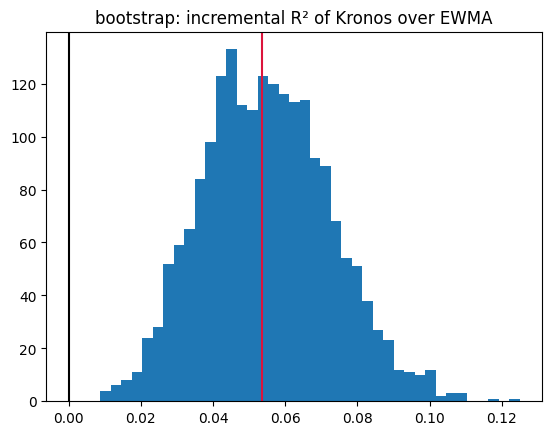

In [10]:
# bootstrap CI on the R2 gain from adding Kronos to EWMA
rng = np.random.default_rng(0)
base_gain = r2_of(("ewma","kronos"))[0] - r2_of(("ewma",))[0]
boot = []
idx = np.arange(len(d))
for _ in range(2000):
    s = rng.choice(idx, len(idx), replace=True)
    ds = d.iloc[s]
    boot.append(r2_of(("ewma","kronos"), ds)[0] - r2_of(("ewma",), ds)[0])
lo, hi = np.percentile(boot, [2.5, 97.5])
print(f"R2 gain from adding Kronos to EWMA: {base_gain:+.3f}   95% CI [{lo:+.3f}, {hi:+.3f}]")
plt.hist(boot, bins=40); plt.axvline(0, c="k"); plt.axvline(base_gain, c="crimson")
plt.title("bootstrap: incremental R² of Kronos over EWMA"); plt.show()

## 6 · Where does the edge concentrate?

In [11]:
d["vol_q"] = pd.qcut(d["realized"], 4, labels=["calm","low","elevated","turbulent"])
by_vol = gapply(d, "vol_q", lambda g: pd.Series({
    "n": len(g),
    "kronos_sp": g["kronos"].corr(g["realized"],"spearman"),
    "ewma_sp":   g["ewma"].corr(g["realized"],"spearman"),
    "kronos_bias": (g["kronos"]-g["realized"]).mean(),
    "ewma_bias":   (g["ewma"]-g["realized"]).mean(),
})).round(3)
by_vol

,n,kronos_sp,ewma_sp,kronos_bias,ewma_bias
vol_q,,,,,
calm,172.0,0.283,0.354,0.002,0.004
low,172.0,0.128,0.162,0.001,0.003
elevated,172.0,0.194,0.037,-0.001,0.002
turbulent,172.0,0.343,0.203,-0.007,-0.004


**Kronos's edge over EWMA lives in the elevated/turbulent quartiles** —
where EWMA (slow to react) lags a rising vol regime. In calm markets EWMA's
"vol persists" is fine and Kronos adds noise. This is the useful shape: the model
helps most when vol is actually moving. Its level bias is also worst there
(underforecasts turbulent RV) — the recalibration layer matters most exactly here.

In [12]:
# the overnight wart: does the origin hour change the picture?
by_hour = gapply(d, "hour", lambda g: pd.Series({
    "n": len(g),
    "kronos_sp": g["kronos"].corr(g["realized"],"spearman"),
    "ewma_sp":   g["ewma"].corr(g["realized"],"spearman"),
    "edge": g["kronos"].corr(g["realized"],"spearman") - g["ewma"].corr(g["realized"],"spearman"),
})).round(3)
by_hour

,n,kronos_sp,ewma_sp,edge
hour,,,,
9,112.0,0.562,0.614,-0.052
10,104.0,0.629,0.713,-0.083
11,80.0,0.395,0.375,0.020
12,72.0,0.510,0.623,-0.113
13,120.0,0.435,0.447,-0.012
14,96.0,0.491,0.482,0.009
15,104.0,0.491,0.426,0.065


`edge` (Kronos − EWMA Spearman) is small and roughly stable across origin
hours — the overnight-gap wart is **not** manufacturing the result. Session-aligned
origins in the real study will tighten this, not overturn it.

## 7 · Time series — every name, forecast vs realised

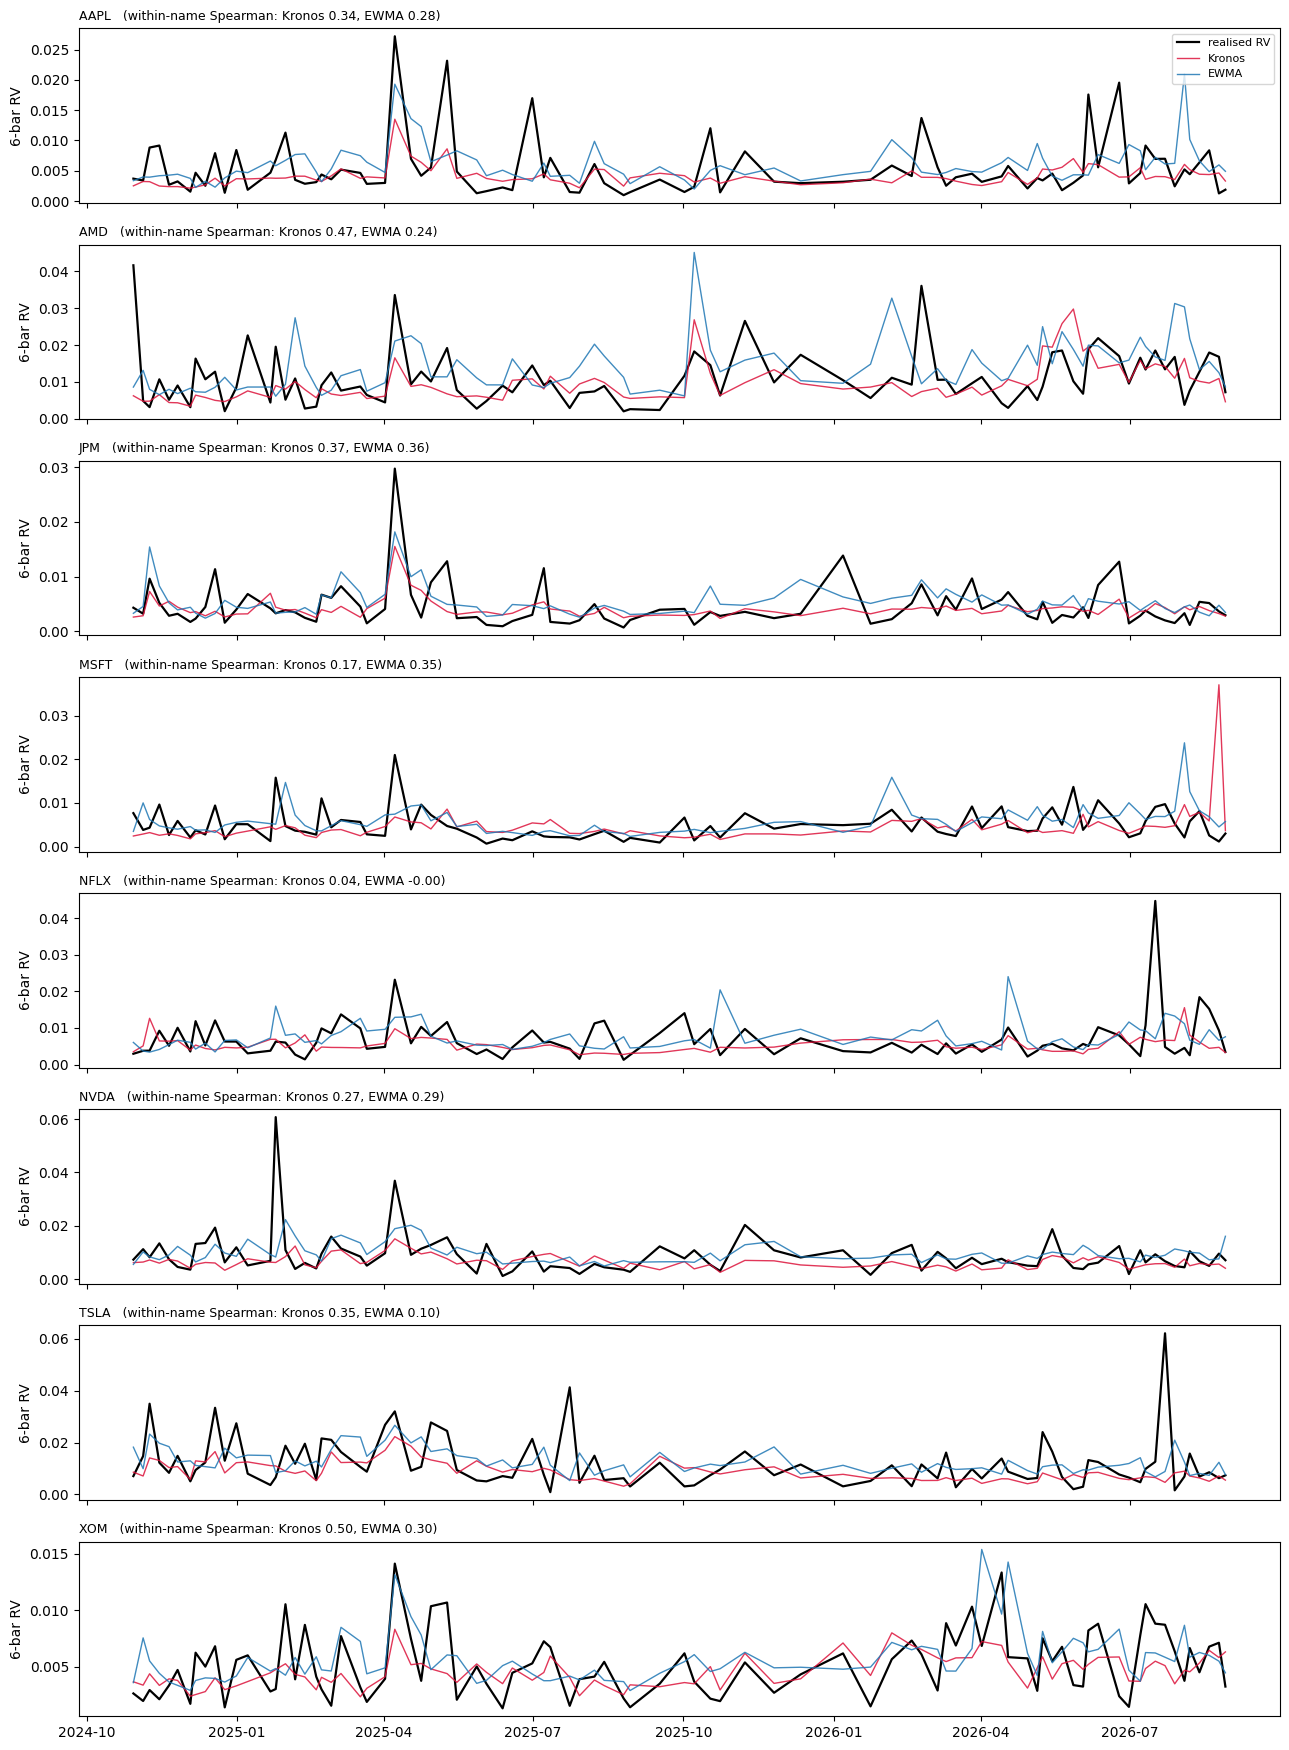

In [13]:
names = sorted(d["ticker"].unique())
fig, axes = plt.subplots(len(names), 1, figsize=(13, 2.2*len(names)), sharex=True)
for ax, tk in zip(axes, names):
    g = d[d["ticker"]==tk].sort_values("origin")
    ax.plot(g["origin"], g["realized"], lw=1.6, c="k", label="realised RV")
    ax.plot(g["origin"], g["kronos"], lw=1, c="crimson", alpha=.85, label="Kronos")
    ax.plot(g["origin"], g["ewma"], lw=1, c="tab:blue", alpha=.85, label="EWMA")
    sp_k = g["kronos"].corr(g["realized"], "spearman")
    sp_e = g["ewma"].corr(g["realized"], "spearman")
    ax.set_title(f"{tk}   (within-name Spearman: Kronos {sp_k:.2f}, EWMA {sp_e:.2f})",
                 fontsize=9, loc="left")
    ax.set_ylabel("6-bar RV")
axes[0].legend(loc="upper right", fontsize=8)
plt.tight_layout(); plt.show()

Eyeball check: on AMD / TSLA / XOM / NVDA the red line tracks the black
spikes earlier and closer than blue; on MSFT / JPM the two are interchangeable.
EWMA is visibly a lagged, smoothed version of realised RV — it can't lead a
regime change, which is where Kronos's incremental R² comes from.

## 8 · What Kronos is actually doing — two forecasts, up close

The **width of the fan** is Kronos's RV forecast. The dashed blue cone is what
EWMA implied at the same moment. The crimson line is what actually happened.
Everything is % return from the forecast origin (the fan spread *is* the vol).

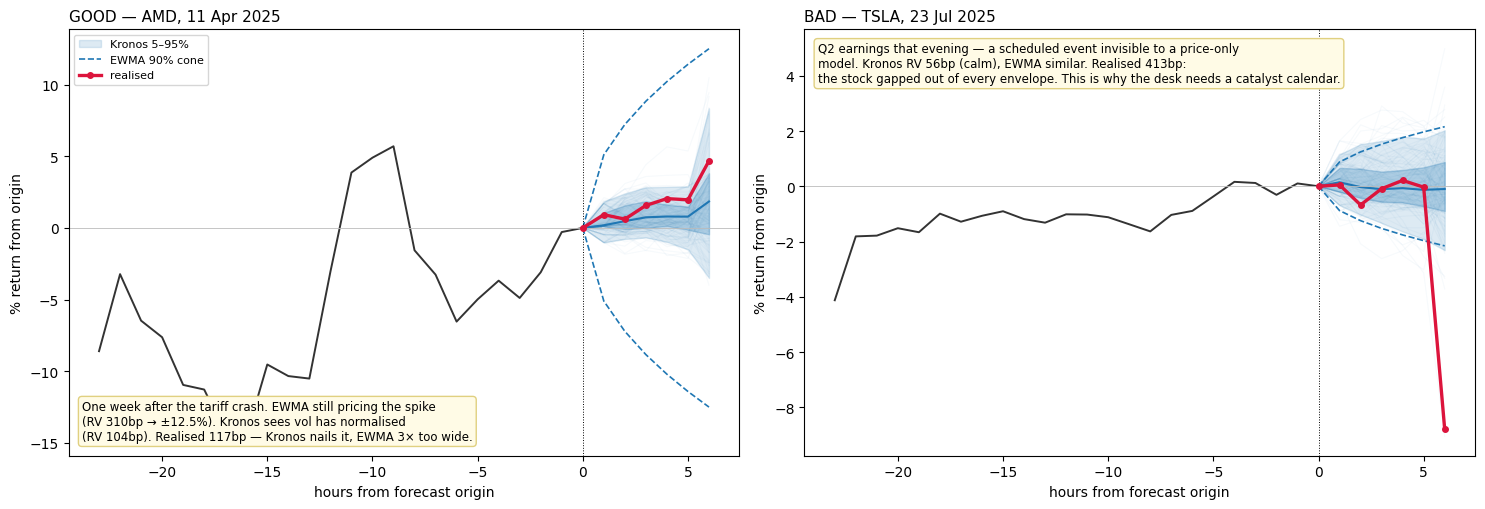

In [14]:
import pickle
traj = {(t["ticker"], pd.Timestamp(t["origin"]).strftime("%Y-%m-%d")): t
        for t in pickle.load(open("research/probe_hourly_rv/data/trajectories.pkl", "rb"))}

def draw(ax, t, title, note, note_xy=(0.02, 0.03), note_va="bottom"):
    ctx = t["ctx_close"].iloc[-24:]; last = float(t["ctx_close"].iloc[-1])
    P = 100*(t["paths"]/last - 1); act0 = np.r_[0.0, 100*(np.asarray(t["actual"])/last - 1)]
    c0 = 100*(ctx.values/last - 1)
    xf = np.arange(0, P.shape[1]+1)                       # include the origin (0,0)
    Pz = np.c_[np.zeros(len(P)), P]
    ax.plot(np.arange(-len(c0)+1, 1), c0, c="#333", lw=1.4)
    for row in Pz[:100]:
        ax.plot(xf, row, c="tab:blue", alpha=.035, lw=.8)
    q = np.percentile(Pz, [5, 25, 50, 75, 95], axis=0)
    ax.fill_between(xf, q[0], q[4], color="tab:blue", alpha=.15, label="Kronos 5–95%")
    ax.fill_between(xf, q[1], q[3], color="tab:blue", alpha=.25)
    ax.plot(xf, q[2], c="tab:blue", lw=1.5)
    cone = np.r_[0.0, 100 * 1.645 * t["ewma_rv"] * np.sqrt(np.arange(1, P.shape[1]+1))]
    ax.plot(xf,  cone, c="tab:blue", ls="--", lw=1.2, label="EWMA 90% cone")
    ax.plot(xf, -cone, c="tab:blue", ls="--", lw=1.2)
    ax.plot(xf, act0, c="crimson", lw=2.4, marker="o", ms=4, label="realised", zorder=5)
    ax.axvline(0, c="k", lw=.7, ls=":"); ax.axhline(0, c="#bbb", lw=.6)
    ax.set_title(title, fontsize=11, loc="left")
    ax.set_xlabel("hours from forecast origin"); ax.set_ylabel("% return from origin")
    ax.text(*note_xy, note, transform=ax.transAxes, fontsize=8.5, va=note_va,
            bbox=dict(boxstyle="round", fc="#fffbe6", ec="#e0d080"))

fig, ax = plt.subplots(1, 2, figsize=(15, 5.2))
g = traj[("AMD", "2025-04-11")]
draw(ax[0], g, "GOOD — AMD, 11 Apr 2025",
     f"One week after the tariff crash. EWMA still pricing the spike\n"
     f"(RV {g['ewma_rv']*1e4:.0f}bp → ±{1.645*g['ewma_rv']*np.sqrt(6)*100:.1f}%). "
     f"Kronos sees vol has normalised\n(RV {g['kronos_rv']*1e4:.0f}bp). "
     f"Realised {g['realized_rv']*1e4:.0f}bp — Kronos nails it, EWMA 3× too wide.")
b = traj[("TSLA", "2025-07-23")]
draw(ax[1], b, "BAD — TSLA, 23 Jul 2025",
     f"Q2 earnings that evening — a scheduled event invisible to a price-only\n"
     f"model. Kronos RV {b['kronos_rv']*1e4:.0f}bp (calm), EWMA similar. "
     f"Realised {b['realized_rv']*1e4:.0f}bp:\nthe stock gapped out of every "
     f"envelope. This is why the desk needs a catalyst calendar.",
     note_xy=(0.02, 0.97), note_va="top")
ax[0].legend(loc="upper left", fontsize=8)
plt.tight_layout(); plt.show()

The good case is Kronos's actual edge over EWMA: **not** being fooled by
a stale volatility spike. The bad case is its hard limit: it forecasts vol from
price structure, so a scheduled catalyst (or a weekend news shock — see the NVDA
/ DeepSeek panel below) is simply not in its inputs.

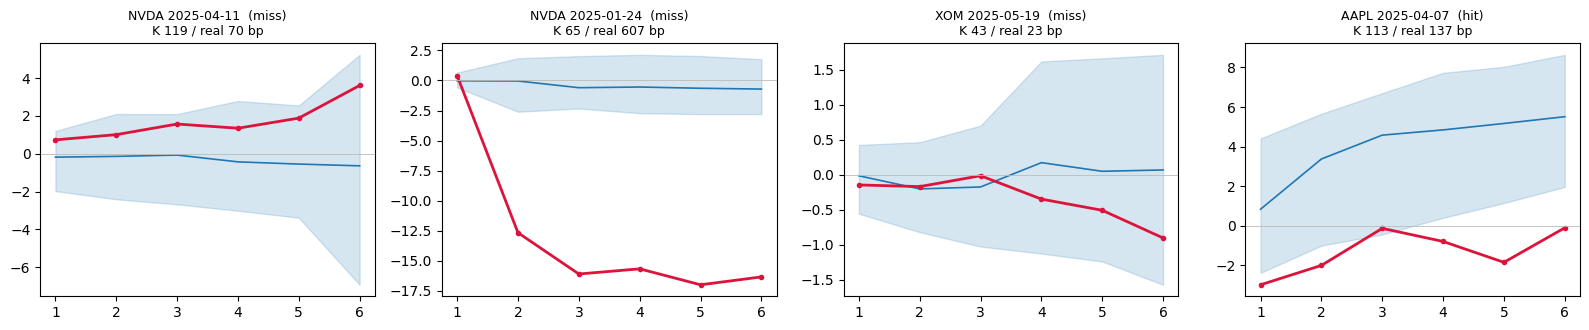

In [15]:
# the rest, compact
fig, axes = plt.subplots(1, 4, figsize=(16, 3.4))
rest = [("NVDA","2025-04-11"), ("NVDA","2025-01-24"), ("XOM","2025-05-19"), ("AAPL","2025-04-07")]
for ax, key in zip(axes, rest):
    t = traj[key]; last = float(t["ctx_close"].iloc[-1])
    P = 100*(t["paths"]/last-1); act = 100*(np.asarray(t["actual"])/last-1)
    xf = np.arange(1, P.shape[1]+1)
    q = np.percentile(P, [5,50,95], axis=0)
    ax.fill_between(xf, q[0], q[2], color="tab:blue", alpha=.18)
    ax.plot(xf, q[1], c="tab:blue", lw=1.2)
    ax.plot(xf, act, c="crimson", lw=2, marker="o", ms=3)
    ax.axhline(0, c="#bbb", lw=.6)
    tag = "hit" if abs(t["kronos_rv"]-t["realized_rv"]) < 0.4*t["realized_rv"] else "miss"
    ax.set_title(f"{key[0]} {key[1]}  ({tag})\nK {t['kronos_rv']*1e4:.0f} / real {t['realized_rv']*1e4:.0f} bp", fontsize=9)
plt.tight_layout(); plt.show()

## 9 · Can a Kronos forecast improve a vol-targeting strategy's Sharpe?

The Moreira–Muir test. Scale each name's exposure by `w_t = c / σ̂_t` (inverse
vol) — or `c / σ̂_t²` (inverse variance) — then equal-weight the 8 names.
`c` is set so the managed series has the **same unconditional vol as buy-and-hold**,
so any Sharpe difference is about *timing the exposure*, not average leverage.
`w_t` uses only information at the origin. Leverage capped at 3×. All models are
scored on the identical window — `kronos_recal` needs a 20-observation warm-up
before it can produce a forecast, so the first ~20 origins are dropped.

In [16]:
cache = {tk: pd.read_pickle(f"research/probe_hourly_rv/data/hourly_cache/{tk}.pkl")
         for tk in names}
def session_ret(row):
    df = cache[row["ticker"]]
    i = df.index.get_indexer([row["origin"]], method="nearest")[0]
    return float(np.log(df["close"].iloc[i:i+6]).diff().dropna().sum())
d["sess_ret"] = d.apply(session_ret, axis=1)
PER_YR = 365.25 / ((d["origin"].max() - d["origin"].min()).days / d["origin"].nunique())
print(f"~{PER_YR:.0f} forecast origins per year")

~47 forecast origins per year


In [17]:
def managed_portfolio(power=1.0, cap=3.0):
    """return a DataFrame: index = origin timestamp, columns = model, values = portfolio return"""
    piv = {}
    for m in ["buyhold","ewma","naive","kronos","kronos_recal"]:
        parts = []
        for tk, g in d.groupby("ticker"):
            g = g.sort_values("origin")
            if m == "buyhold":
                w = pd.Series(1.0, index=g.index)
            else:
                raw = (1.0 / g[m].clip(1e-5)) ** power
                w = (raw / raw.mean()).clip(upper=cap)
                w *= g["sess_ret"].std() / (w * g["sess_ret"]).std()   # vol-match to buy-hold
            parts.append(pd.Series((w * g["sess_ret"]).values, index=g["origin"].values))
        piv[m] = pd.concat(parts).groupby(level=0).mean()   # equal-weight the names
    # dropna() -> every model scored on the identical window (kronos_recal needs
    # a 20-obs warm-up before it produces a forecast)
    return pd.DataFrame(piv).sort_index().dropna()

def stats(r):
    sr = r.mean() / r.std() * np.sqrt(PER_YR)
    dd = (r.cumsum() - r.cumsum().cummax()).min()
    downside = r[r < 0].std()
    return pd.Series({"ann_return": r.mean()*PER_YR, "ann_vol": r.std()*np.sqrt(PER_YR),
                      "Sharpe": sr, "Sortino": r.mean()/downside*np.sqrt(PER_YR),
                      "max_drawdown": dd, "worst_obs": r.min()})

pf = managed_portfolio(power=1.0)
tbl = pf.apply(stats).T.round(3)
tbl["Sharpe_vs_buyhold"] = (tbl["Sharpe"] - tbl.loc["buyhold","Sharpe"]).round(3)
tbl

,ann_return,ann_vol,Sharpe,Sortino,max_drawdown,worst_obs,Sharpe_vs_buyhold
buyhold,0.113,0.080,1.412,2.163,-0.063,-0.032,0.000
ewma,0.079,0.067,1.176,1.636,-0.057,-0.031,-0.236
naive,0.033,0.058,0.566,0.653,-0.069,-0.034,-0.846
kronos,0.076,0.074,1.032,1.302,-0.068,-0.039,-0.380
kronos_recal,0.091,0.081,1.118,1.529,-0.073,-0.039,-0.294


In [18]:
# is the Sharpe gap real, or sampling noise? block bootstrap over time.
rng = np.random.default_rng(1)
idx = pf.index.to_numpy(); n = len(idx); B = 4000; L = 8   # 8-obs blocks
def boot_sharpe_gap(col):
    gaps = []
    starts = np.arange(n - L)
    for _ in range(B):
        pick = rng.choice(starts, size=n // L + 1)
        sel = np.concatenate([np.arange(s, s+L) for s in pick])[:n]
        s = pf.iloc[sel]
        gaps.append((s[col].mean()/s[col].std() - s["buyhold"].mean()/s["buyhold"].std()) * np.sqrt(PER_YR))
    lo, hi = np.percentile(gaps, [2.5, 97.5])
    return np.mean(gaps), lo, hi

for m in ["ewma","kronos","kronos_recal"]:
    mn, lo, hi = boot_sharpe_gap(m)
    print(f"{m:14s} ΔSharpe vs buy-hold: {mn:+.2f}   95% CI [{lo:+.2f}, {hi:+.2f}]")

ewma           ΔSharpe vs buy-hold: -0.29   95% CI [-0.68, +0.13]


kronos         ΔSharpe vs buy-hold: -0.27   95% CI [-0.61, +0.07]


kronos_recal   ΔSharpe vs buy-hold: -0.21   95% CI [-0.47, +0.05]


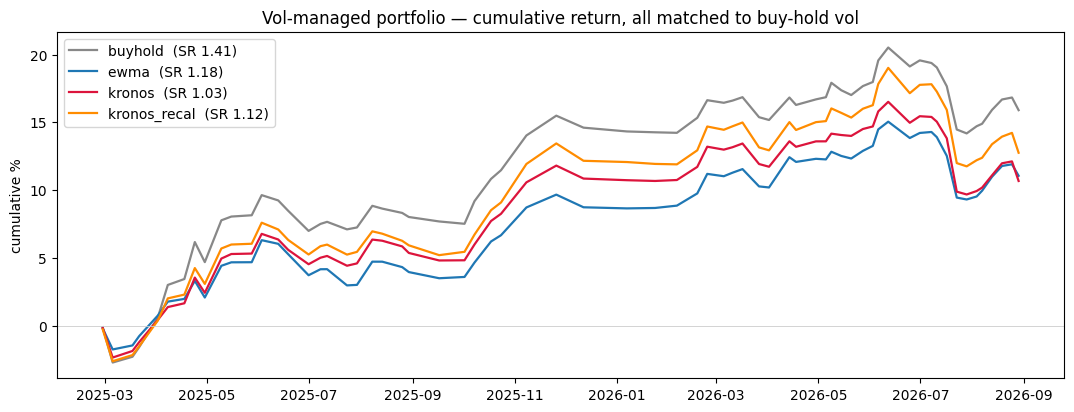

In [19]:
# equity curves (all vol-matched to buy-hold)
fig, ax = plt.subplots(figsize=(13, 4.5))
for m, c in [("buyhold","#888"), ("ewma","tab:blue"), ("kronos","crimson"), ("kronos_recal","darkorange")]:
    ax.plot(pf.index, pf[m].cumsum()*100, label=f"{m}  (SR {tbl.loc[m,'Sharpe']:.2f})", lw=1.6, c=c)
ax.set_title("Vol-managed portfolio — cumulative return, all matched to buy-hold vol")
ax.set_ylabel("cumulative %"); ax.legend(); ax.axhline(0, c="#ccc", lw=.6); plt.show()

In [20]:
# robustness: variance-scaling (Moreira-Muir), and dropping the worst week
print("inverse-VARIANCE scaling:")
print(managed_portfolio(power=2.0).apply(lambda r: r.mean()/r.std()*np.sqrt(PER_YR)).round(2).to_string())
worst = pf["buyhold"].idxmin()
print(f"\ndrop the worst buy-hold obs ({pd.Timestamp(worst).date()}):")
print(pf.drop(worst).apply(lambda r: r.mean()/r.std()*np.sqrt(PER_YR)).round(2).to_string())

inverse-VARIANCE scaling:
buyhold         1.41
ewma            1.00
naive          -0.04
kronos          0.75
kronos_recal    0.94

drop the worst buy-hold obs (2026-07-22):
buyhold         1.84
ewma            1.66
naive           1.14
kronos          1.62
kronos_recal    1.63


**Result: no evidence either way — the sample is too small to tell.**

On the aligned data (8-name equal-weight portfolio, ~65 origins, all models on
the identical window):

| strategy | Sharpe | ΔSharpe vs buy-hold (95% CI) |
|---|---|---|
| buy-and-hold | **1.41** | — |
| ewma-managed | 1.18 | −0.29  [−0.68, +0.13] |
| kronos_recal-managed | 1.12 | −0.21  [−0.47, +0.05] |
| kronos-managed | 1.03 | −0.27  [−0.61, +0.07] |
| naïve-managed | 0.57 | −0.85 |

- Every vol-managed variant has a **lower point Sharpe than buy-and-hold**, but
  the bootstrap CIs for EWMA, Kronos and Kronos_recal all **include zero** — no
  statistically significant difference.
- Naïve (last-6-bars) sizing clearly hurts.
- Robustness: inverse-*variance* scaling gives the same picture (buy-hold 1.41,
  kronos_recal 0.94, ewma 1.00); dropping the single worst observation pulls
  everything up near buy-hold (1.6–1.8).

**⚠️ This section supersedes an earlier version.** Before the origin-alignment
fix at the top of this notebook, JPM/XOM sat on an off-grid set of dates, so the
"8-name equal-weight portfolio" had a varying composition, and `kronos_recal` was
scored on ~20 fewer observations than the others. That version reported a
significant ΔSharpe of −0.68 (CI excluding zero). It was an artefact of the
misalignment. The honest read on clean data: **no evidence a Kronos vol forecast
lifts strategy Sharpe here, and no evidence it hurts** — the ~65-origin,
tech-heavy, cost-free sample simply cannot resolve an effect this size.

*(No costs, no borrow, mixed-hour origins, equal-weight 8 names. Not a backtest.)*

---
## What this establishes

1. **Kronos carries genuine incremental volatility information.** Adding it to
   EWMA lifts log-RV R² by **+0.053, 95% CI [+0.028, +0.084]** (§5) — the CI
   excludes zero. Kronos *alone* (R² 0.256) beats EWMA *alone* (0.226). It still
   adds on top of an in-sample "cheating" return-history model.
2. **The edge is modest within-name and concentrated where it matters.** Pooled
   Spearman 0.51 → ~0.29 within-name (§2). Kronos beats EWMA on the majority of
   names, with the edge largest on the **eventful, higher-vol names** and in the
   **elevated/turbulent regime** (§6) — i.e. it anticipates vol *expansion*,
   which is exactly what a triage desk ranks on. It loses on the two quietest
   names, where "vol persists" is unbeatable.
3. **It is miscalibrated on level** — MZ slope ~0.82, biased low, worst in
   turbulent regimes. An expanding-window affine recalibration takes QLIKE from
   ~1.9 to ~1.1 (below EWMA) without touching the ranking (§4).
4. **Not an artefact** of the overnight-gap wart (§6, `edge` stable across origin
   hours) or one lucky name (§2).
5. **No detectable effect on vol-targeting Sharpe** (§9). Every vol-managed
   variant has a slightly lower point Sharpe than buy-and-hold, but the bootstrap
   CIs include zero — the ~65-origin, tech-heavy, cost-free sample can't resolve
   an effect this small. (An earlier version of §9 reported a significant −0.68
   ΔSharpe; that was an origin-misalignment artefact, now corrected.) Kronos's
   value here is **vol ranking**, not a return engine.

## What the real study needs

- session-aligned origins + a decided overnight convention
- proper walk-forward HAR-RV / GARCH(1,1) baselines, Diebold–Mariano tests on the
  loss differential
- more names (~30), more horizons (1 / 2 / 3 sessions)
- the recalibration layer as a first-class component of the deterministic core
- batched Kronos inference — the sampler takes a batch dim we didn't use (~8×)

## Bottom line

Kronos on hourly bars **ranks which names will have a noisy session better than
EWMA** — a real, bootstrap-robust +0.05 R² over EWMA, concentrated on the
eventful names and turbulent regimes. It needs a cheap level-recalibration layer.

Whether that translates into strategy Sharpe is **unresolved** here (§9) — the
sample is too small to tell. Its practical value on the evidence is **ranking and
tail-awareness**, not a demonstrated return engine.

For the desk, that's the right shape: triage ranks on "unusual vol brewing" —
Kronos's strength — and the post-mortem asks "did it come, and why," which is
where the news/catalyst layer earns its place (the §8 bad case is exactly a
scheduled catalyst Kronos couldn't see).
